In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from nba_api.stats.endpoints import leaguedashplayerstats


Matplotlib is building the font cache; this may take a moment.


# Most Efficient High-Usage Scorers (2024–25 NBA Season)

**Goal:** Identify the most efficient *high-usage* scorers in the 2024–25 regular season.

**Metric:** True Shooting Percentage (TS%)

**Why filter by FGA?**  
Raw TS% leaderboards can be dominated by low-usage finishers (often big men scoring mostly at the rim).  
To focus on “superstar context” scoring responsibility, we apply:

**High-usage filter:** `FGA ≥ 1000`

In [5]:
from nba_api.stats.endpoints import leaguedashplayerstats

league = leaguedashplayerstats.LeagueDashPlayerStats(
    season="2024-25",
    season_type_all_star="Regular Season"
).get_data_frames()[0]

league.head()

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1630639,A.J. Lawson,A.J.,1610612761,TOR,24.0,26,14,12,0.538,...,241,200,327,337,299,375,159,44,364,1
1,1631260,AJ Green,AJ,1610612749,MIL,25.0,73,44,29,0.603,...,99,498,290,214,62,247,281,44,225,1
2,1642358,AJ Johnson,AJ,1610612764,WAS,20.0,29,8,21,0.276,...,312,217,369,347,495,379,281,44,372,2
3,203932,Aaron Gordon,Aaron,1610612743,DEN,29.0,51,33,18,0.647,...,451,301,107,139,41,183,134,44,181,1
4,1628988,Aaron Holiday,Aaron,1610612745,HOU,28.0,62,39,23,0.629,...,224,259,292,292,115,322,281,44,315,1


In [6]:
df = league.copy()
df = df[df["FGA"] > 0].copy()

df["TS_PCT"] = df["PTS"] / (2 * (df["FGA"] + 0.44 * df["FTA"]))

df_fga = df[df["FGA"] >= 1000].sort_values("TS_PCT", ascending=False).copy()

df_fga[["PLAYER_NAME", "PTS", "FGA", "TS_PCT", "MIN"]].head(10)

,PLAYER_NAME,PTS,FGA,TS_PCT,MIN
423,Nikola Jokić,2071,1364,0.662745,2570.765000
330,Kevin Durant,1647,1124,0.641935,2264.685000
564,Zach LaVine,1724,1223,0.639276,2602.480000
490,Shai Gilgeous-Alexander,2484,1656,0.636806,2597.630000
314,Karl-Anthony Towns,1759,1215,0.630484,2516.720000
180,Giannis Antetokounmpo,2036,1319,0.624509,2288.630000
498,Stephen Curry,1718,1258,0.618181,2252.450000
397,Michael Porter Jr.,1398,1048,0.616750,2593.263333
543,Tyrese Haliburton,1359,1006,0.615668,2450.391667
36,Austin Reaves,1475,1037,0.615589,2550.091667


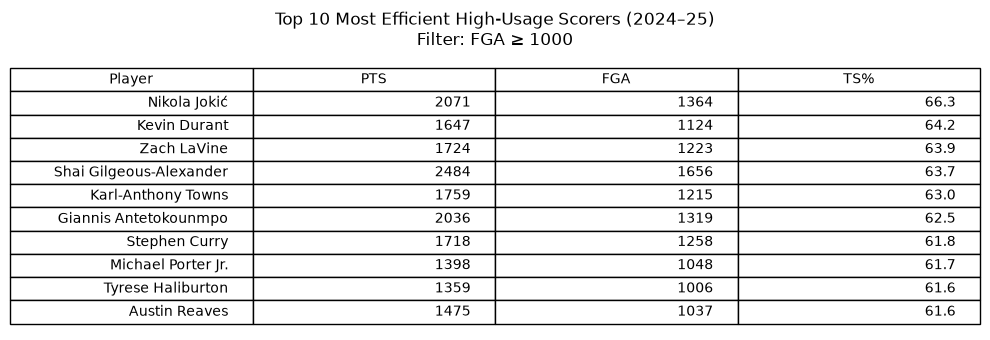

In [7]:
os.makedirs("../reports", exist_ok=True)

top10 = df_fga[["PLAYER_NAME", "PTS", "FGA", "TS_PCT"]].head(10).copy()
top10["TS_PCT"] = (top10["TS_PCT"] * 100).round(1)  # convert to %

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")

table = ax.table(
    cellText=top10.values,
    colLabels=["Player", "PTS", "FGA", "TS%"],
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.title("Top 10 Most Efficient High-Usage Scorers (2024–25)\nFilter: FGA ≥ 1000", pad=12)
plt.tight_layout()
plt.savefig("../reports/top10_efficient_scorers_2024_25.png", dpi=250)
plt.show()


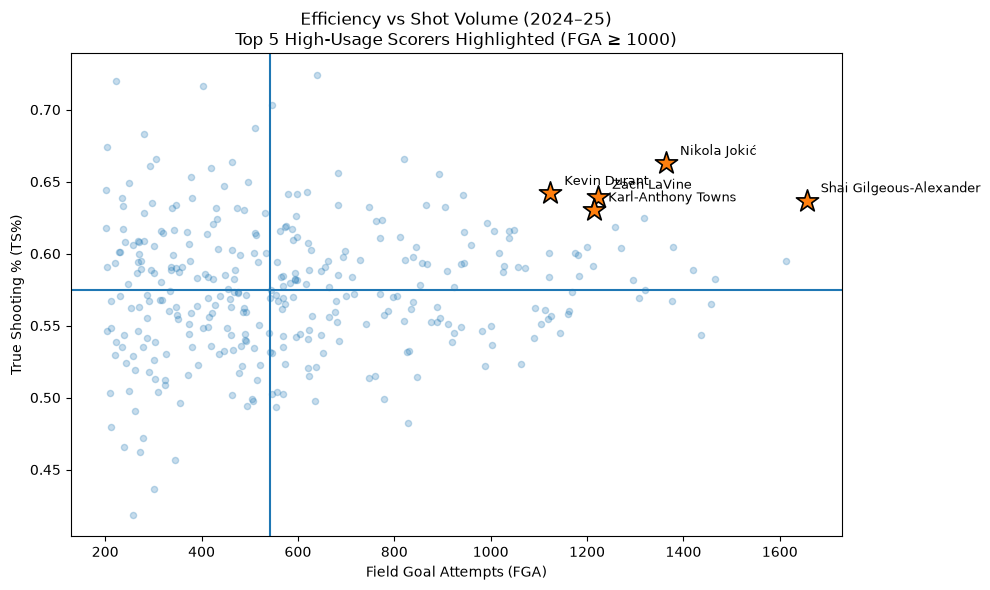

In [8]:
plot_df = df[df["FGA"] >= 200].copy()          # remove tiny-sample players for clearer plot
top5 = df_fga.head(5).copy()

median_ts = plot_df["TS_PCT"].median()
median_fga = plot_df["FGA"].median()

plt.figure(figsize=(10, 6))

# all players (faint)
plt.scatter(plot_df["FGA"], plot_df["TS_PCT"], alpha=0.25, s=20)

# top 5 (big star marker with outline)
plt.scatter(
    top5["FGA"], top5["TS_PCT"],
    s=280, marker="*",
    edgecolors="black", linewidths=1.2,
    zorder=5
)

# labels
for _, row in top5.iterrows():
    plt.annotate(
        row["PLAYER_NAME"],
        (row["FGA"], row["TS_PCT"]),
        textcoords="offset points",
        xytext=(10, 6),
        fontsize=9,
        zorder=6
    )

# quadrant lines
plt.axhline(median_ts)
plt.axvline(median_fga)

plt.title("Efficiency vs Shot Volume (2024–25)\nTop 5 High-Usage Scorers Highlighted (FGA ≥ 1000)")
plt.xlabel("Field Goal Attempts (FGA)")
plt.ylabel("True Shooting % (TS%)")

plt.tight_layout()
plt.savefig("../reports/efficiency_vs_shot_volume_2024_25.png", dpi=300)
plt.show()


## Key Findings

- Using TS% with a high-usage filter (FGA ≥ 1000) isolates primary scoring options rather than low-volume finishers.
- Nikola Jokić ranks as the most efficient high-usage scorer in the 2024–25 regular season.
- The scatter plot shows how a small group of players combine both high shot volume and elite efficiency.
